
===== NAMA KOLOM =====
['no', 'datetime', 'device_name', 'location', 'energy_consumption_(kwh)']

===== CEK DATETIME =====
0   2025-12-14 22:00:00
1   2025-12-14 22:00:00
2   2025-12-14 22:00:00
3   2025-12-14 22:00:00
4   2025-12-14 22:00:00
Name: Date_Time, dtype: datetime64[us]
Jumlah NaT: 0

===== MISSING VALUE SEBELUM =====
no                0
Date_Time         0
device_name       0
location          0
kWh            1631
dtype: int64

===== MISSING VALUE SESUDAH =====
no             0
Date_Time      0
device_name    0
location       0
kWh            0
dtype: int64

===== CEK NILAI kWh =====
Minimum: 10017.45
Maximum: 378853.23
Jumlah Data: 7238


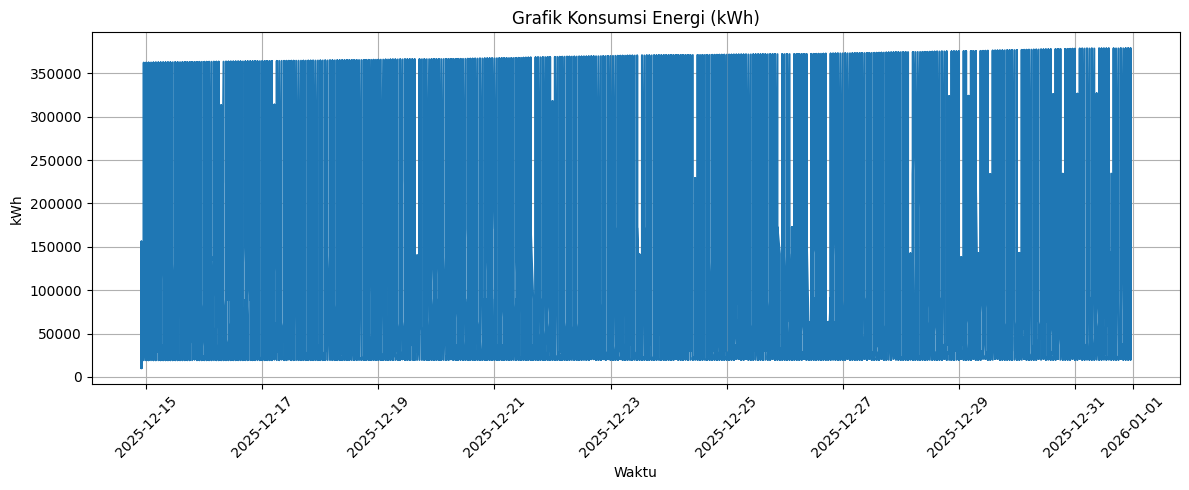


===== DATA NORMALISASI =====
            kWh  kWh_normalisasi
0      10207.86         0.000516
1      12433.85         0.006551
2      14458.19         0.012040
3      10017.45         0.000000
4      66765.75         0.153858
5     156071.48         0.395987
6      30989.72         0.056861
21     61979.88         0.140882
20    138663.05         0.348788
19     39591.59         0.080182
18     20035.34         0.027161
17    362202.17         0.954855
16     28916.93         0.051241
15     36111.70         0.070748
14     21726.06         0.031745
13     32059.76         0.059762
12     22446.61         0.033698
11     22792.44         0.034636
10     24867.70         0.040262
9      20415.72         0.028192
8      38341.80         0.076794
7      19219.54         0.024949
38     61980.35         0.140884
37    138675.52         0.348822
36    133545.12         0.334912
35     39594.61         0.080191
34     44381.18         0.093168
32    362267.58         0.955032
31     28917.

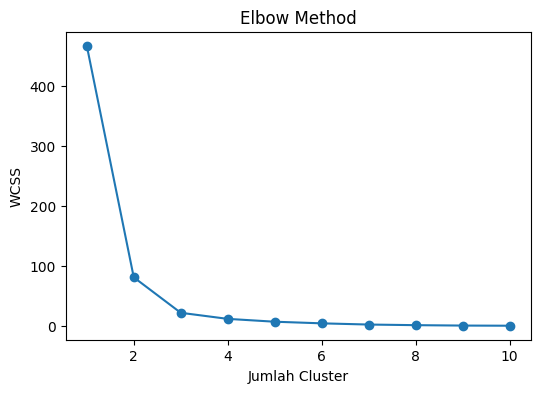


===== HASIL CLUSTER =====
            kWh  Cluster
0      10207.86        0
1      12433.85        0
2      14458.19        0
3      10017.45        0
4      66765.75        0
5     156071.48        2
6      30989.72        0
21     61979.88        0
20    138663.05        2
19     39591.59        0
18     20035.34        0
17    362202.17        1
16     28916.93        0
15     36111.70        0
14     21726.06        0
13     32059.76        0
12     22446.61        0
11     22792.44        0
10     24867.70        0
9      20415.72        0
8      38341.80        0
7      19219.54        0
38     61980.35        0
37    138675.52        2
36    133545.12        2
35     39594.61        0
34     44381.18        0
32    362267.58        1
31     28917.84        0
30     36112.54        0
33     20036.12        0
28     32059.76        0
22     19219.54        0
23     38341.80        0
24     20415.72        0
29     21726.06        0
26     22792.44        0
27     22446.64        

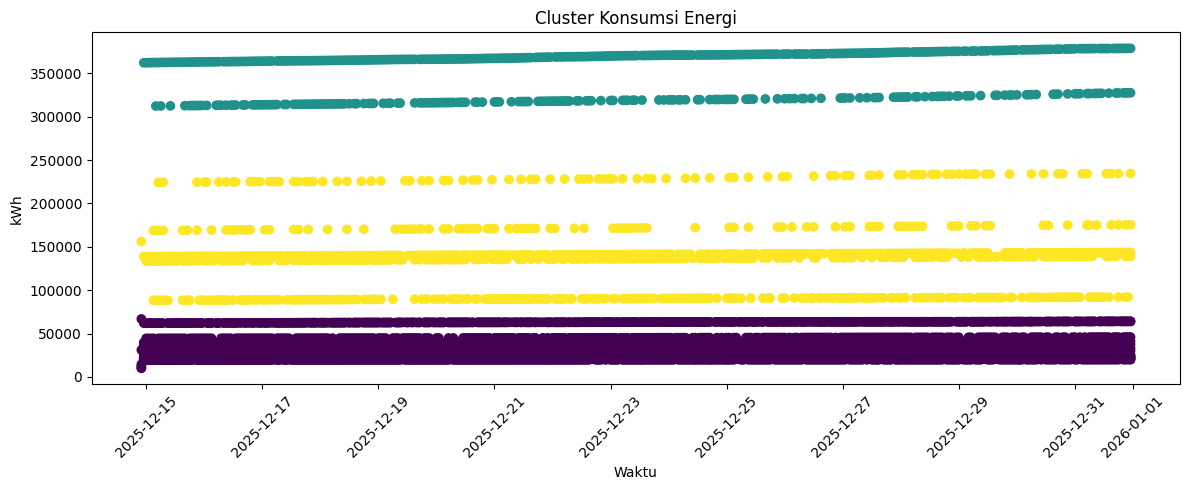

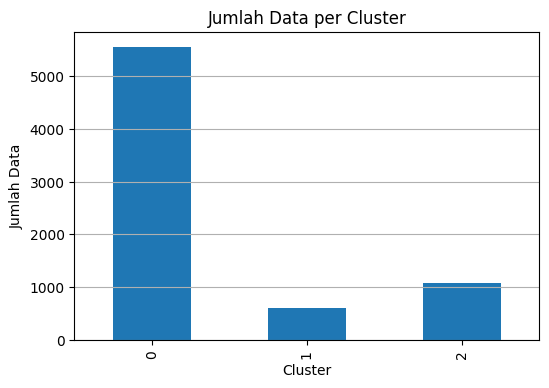

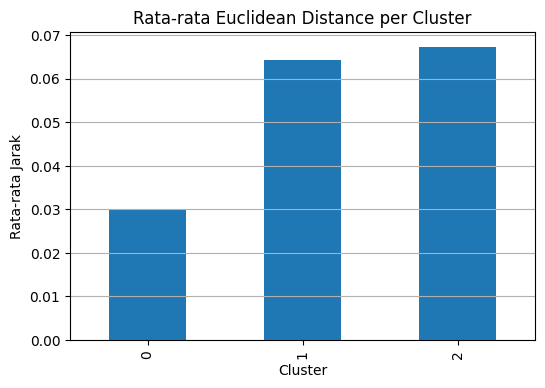

In [3]:
# =====================================================
# IMPORT LIBRARY
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =====================================================
# READ CSV
# =====================================================
df = pd.read_csv("Data Per Jam Desember.csv", encoding="utf-8")

# =====================================================
# RAPIIKAN NAMA KOLOM
# =====================================================
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

print("\n===== NAMA KOLOM =====")
print(df.columns.tolist())

# =====================================================
# DETEKSI KOLOM kWh
# =====================================================
kolom_kwh = [col for col in df.columns if 'kwh' in col or 'energy' in col]

if len(kolom_kwh) > 0:
    df = df.rename(columns={kolom_kwh[0]: 'kWh'})
else:
    raise ValueError("Kolom kWh / energy tidak ditemukan!")

# =====================================================
# DETEKSI KOLOM WAKTU
# =====================================================
kolom_waktu = [col for col in df.columns if 'date' in col or 'time' in col or 'datetime' in col]

if len(kolom_waktu) > 0:
    df = df.rename(columns={kolom_waktu[0]: 'Date_Time'})
else:
    raise ValueError("Kolom waktu tidak ditemukan!")

# =====================================================
# PERBAIKI FORMAT DATETIME
# =====================================================
# Format asli: "22, 14/12/25"
df[['Hour', 'Date']] = df['Date_Time'].astype(str).str.split(',', expand=True)

df['Hour'] = df['Hour'].str.strip()
df['Date'] = df['Date'].str.strip()

# Gabungkan jadi datetime lengkap
df['Date_Time'] = df['Date'] + ' ' + df['Hour'] + ':00'

# Convert ke datetime
df['Date_Time'] = pd.to_datetime(
    df['Date_Time'],
    format='%d/%m/%y %H:%M',
    errors='coerce'
)

# Hapus kolom sementara
df = df.drop(columns=['Hour', 'Date'])

print("\n===== CEK DATETIME =====")
print(df['Date_Time'].head())
print("Jumlah NaT:", df['Date_Time'].isna().sum())

# =====================================================
# PERBAIKI FORMAT kWh
# =====================================================
df['kWh'] = df['kWh'].astype(str).str.replace(',', '').str.replace(' ', '')
df['kWh'] = pd.to_numeric(df['kWh'], errors='coerce')

# =====================================================
# CLEANING DATA
# =====================================================
print("\n===== MISSING VALUE SEBELUM =====")
print(df.isnull().sum())

df = df.dropna(subset=['kWh', 'Date_Time'])
df = df.reset_index(drop=True)

print("\n===== MISSING VALUE SESUDAH =====")
print(df.isnull().sum())

# =====================================================
# CEK NILAI kWh
# =====================================================
print("\n===== CEK NILAI kWh =====")
print("Minimum:", df['kWh'].min())
print("Maximum:", df['kWh'].max())
print("Jumlah Data:", len(df))

# =====================================================
# URUTKAN DATA WAKTU
# =====================================================
df = df.sort_values('Date_Time')

# =====================================================
# GRAFIK KONSUMSI ENERGI
# =====================================================
plt.figure(figsize=(12, 5))
plt.plot(df['Date_Time'], df['kWh'])
plt.title("Grafik Konsumsi Energi (kWh)")
plt.xlabel("Waktu")
plt.ylabel("kWh")
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================
# NORMALISASI MIN MAX
# =====================================================
scaler = MinMaxScaler()
df['kWh_normalisasi'] = scaler.fit_transform(df[['kWh']])

print("\n===== DATA NORMALISASI =====")
print(df[['kWh', 'kWh_normalisasi']])

# =====================================================
# ELBOW METHOD
# =====================================================
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df[['kWh_normalisasi']])
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.show()

# =====================================================
# K-MEANS CLUSTERING
# =====================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['kWh_normalisasi']])

print("\n===== HASIL CLUSTER =====")
print(df[['kWh', 'Cluster']])

# =====================================================
# CENTROID
# =====================================================
centroids = kmeans.cluster_centers_

print("\n===== CENTROID =====")
for i, c in enumerate(centroids):
    print(f"Cluster {i}: {c[0]}")

# =====================================================
# EUCLIDEAN DISTANCE
# =====================================================
df['Euclidean_Distance'] = abs(
    df['kWh_normalisasi'] - df['Cluster'].map(lambda x: centroids[x][0])
)

print("\n===== DATA + JARAK =====")
print(df[['kWh', 'kWh_normalisasi', 'Cluster', 'Euclidean_Distance']])

# =====================================================
# JUMLAH DATA PER CLUSTER
# =====================================================
print("\n===== JUMLAH DATA PER CLUSTER =====")

cluster_count = df['Cluster'].value_counts().sort_index()

for i in range(3):
    print(f"Cluster {i}: {cluster_count.get(i, 0)} data")

# =====================================================
# ANALISIS EUCLIDEAN DISTANCE
# =====================================================
print("\n===== ANALISIS EUCLIDEAN DISTANCE PER CLUSTER =====")

cluster_analysis = df.groupby('Cluster')['Euclidean_Distance'].agg(['count', 'mean', 'sum'])
cluster_analysis.columns = ['Jumlah_Data', 'Rata_Rata_Jarak', 'Total_Jarak']

print(cluster_analysis)

# =====================================================
# VISUALISASI CLUSTER
# =====================================================
plt.figure(figsize=(12, 5))
plt.scatter(df['Date_Time'], df['kWh'], c=df['Cluster'])
plt.title("Cluster Konsumsi Energi")
plt.xlabel("Waktu")
plt.ylabel("kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================
# VISUALISASI JUMLAH CLUSTER
# =====================================================
plt.figure(figsize=(6, 4))
cluster_count.sort_index().plot(kind='bar')
plt.title("Jumlah Data per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.grid(axis='y')
plt.show()

# =====================================================
# VISUALISASI RATA-RATA JARAK
# =====================================================
plt.figure(figsize=(6, 4))
cluster_analysis['Rata_Rata_Jarak'].plot(kind='bar')
plt.title("Rata-rata Euclidean Distance per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Rata-rata Jarak")
plt.grid(axis='y')
plt.show()